# Performance by supervision mode — Triage game
**Only validated participants (`Valido == 'si'`) are included.**

Test-phase analysis only. Three outcomes:
- **Total score** (max 30)
- **Selection score** (max 15)
- **Destination score** (max 15)


In [22]:
import sys
print(sys.executable)

/Users/MartiLlairo/opt/anaconda3/envs/tfm/bin/python


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import shapiro, probplot
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")


%matplotlib inline
plt.rcParams["figure.dpi"] = 130


## Configuration

In [28]:
# ── Update this path to point to your CSV ────────────────────────────────────
DATA_PATH = "triage_data_last_v3.csv"


## Load and filter data

In [29]:
# ════════════════════════════════════════════════════════════════════════════
# SETUP CELL — run this first after any kernel restart
# Defines all derived DataFrames used throughout the notebook.
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, probplot
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings("ignore")

# ── Shared plot config ────────────────────────────────────────────────────────
COLORS = {"guided": "#7F77DD", "error_based": "#1D9E75"}
MODES  = ["guided", "error_based"]
X      = {"guided": 0.25, "error_based": 0.75}
rng    = np.random.default_rng(42)

# ── Load data ─────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, sep=",")

# ── Valid participants ────────────────────────────────────────────────────────
VALID_IDS = [
    'P044', 'P043', 'P042', 'P040', 'P038', 'P036', 'P035',
    'P026', 'P025', 'P022', 'P019', 'P018', 'P017', 'P016',
    'P015', 'P012', 'P010', 'P050', 'P059', 'P060', 'P061'
]
df = df_raw[df_raw["participant_id"].isin(VALID_IDS)].copy()

n_guided = (df["mode"] == "guided").sum()
n_error  = (df["mode"] == "error_based").sum()
print(f"Main df:  N={len(df)}  (guided={n_guided}, error_based={n_error})")

# ── DATA QUALITY CORRECTIONS ──────────────────────────────────────────────────

# P044: misclick on test G1 destinations — set to NaN
df.loc[df["participant_id"] == "P044", "test_g1_destinations_score"] = np.nan

# Recompute destination and total scores to propagate the NaN correctly
dest_cols = ["test_g1_destinations_score",
             "test_g2_destinations_score",
             "test_g3_destinations_score"]
df["test_dest_total"] = df[dest_cols].sum(axis=1, min_count=1)
df["test_total"]      = df["test_sel_total"] + df["test_dest_total"]

# Mean score per group (fair across participants with missing data)
for g in (1, 2, 3):
    df[f"test_g{g}_score"] = (df[f"test_g{g}_selection_score"].fillna(0) +
                               df[f"test_g{g}_destinations_score"])
df["test_score_mean"] = df[["test_g1_score",
                             "test_g2_score",
                             "test_g3_score"]].mean(axis=1)

# Kendall tau total
df["test_kendall_tau_total"] = (df["test_g1_kendall_tau"] +
                                df["test_g2_kendall_tau"] +
                                df["test_g3_kendall_tau"])

# ── OUTLIER CORRECTION — task time (IQR, per participant) ────────────────────
time_cols = [f"test_g{g}_{pt}_time_sec"
             for g in (1, 2, 3) for pt in ("selection", "destinations")]
df["test_task_time_total"] = df[time_cols].fillna(0).sum(axis=1)

Q1, Q3    = df["test_task_time_total"].quantile(0.25), df["test_task_time_total"].quantile(0.75)
upper     = Q3 + 1.5 * (Q3 - Q1)
mean_clean = df.loc[df["test_task_time_total"] <= upper, "test_task_time_total"].mean()
n_out     = (df["test_task_time_total"] > upper).sum()
df.loc[df["test_task_time_total"] > upper, "test_task_time_total"] = mean_clean
print(f"Task time outliers replaced: {n_out}  (upper fence={upper:.0f}s, "
      f"replacement mean={mean_clean:.0f}s)")

# ── NASA-TLX — reverse score performance, compute burden composite ────────────
df["nasa_performance_r"] = 100 - df["nasa_performance"]

BURDEN_DIMS = ["nasa_mental", "nasa_physical", "nasa_temporal",
               "nasa_performance_r", "nasa_effort", "nasa_frustration"]
FOCAL_DIMS  = ["nasa_mental", "nasa_effort", "nasa_frustration"]

df["nasa_burden_mean"] = df[BURDEN_DIMS].mean(axis=1)

# ── DERIVED DATAFRAMES ────────────────────────────────────────────────────────

# df_nasa: P026 excluded (all-default NASA responses)
NASA_EXCLUDE = ["P026"]
df_nasa = df[~df["participant_id"].isin(NASA_EXCLUDE)].copy()
print(f"df_nasa: N={len(df_nasa)}  (P026 excluded — default NASA responses)")

# df_nasa_strip: P026 + P044 excluded (strip plots only)
df_nasa_strip = df_nasa[df_nasa["participant_id"] != "P044"].copy()
print(f"df_nasa_strip: N={len(df_nasa_strip)}  (P026 + P044 excluded — strip plots)")

# df_duration: P017 excluded (session timing artefact ~50h)
df_duration = df[df["participant_id"] != "P017"].copy()
print(f"df_duration: N={len(df_duration)}  (P017 excluded — timing artefact)")

# df_ancova: all 19 participants + frustration from df_nasa (NaN for P026)
df_ancova = df.merge(
    df_nasa[["participant_id", "nasa_frustration"]],
    on="participant_id",
    how="left",
    suffixes=("", "_nasa")
)
# Use the nasa version (NaN for P026) and drop the duplicate column
if "nasa_frustration_nasa" in df_ancova.columns:
    df_ancova["nasa_frustration"] = df_ancova["nasa_frustration_nasa"]
    df_ancova = df_ancova.drop(columns=["nasa_frustration_nasa"])

print(f"df_ancova: N={len(df_ancova)}  "
      f"(P026 nasa_frustration = NaN: "
      f"{df_ancova.loc[df_ancova['participant_id']=='P026','nasa_frustration'].isna().all()})")

# ── Cronbach's alpha utility ──────────────────────────────────────────────────
def cronbach_alpha(df_items):
    k         = df_items.shape[1]
    item_var  = df_items.var(axis=0, ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

# ── Strip panel utility ───────────────────────────────────────────────────────
def strip_panel(ax, data, col, title, y_max, y_min=None):
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    for mode in MODES:
        vals = data.loc[data["mode"] == mode, col].dropna().reset_index(drop=True)
        x0, c = X[mode], COLORS[mode]
        xs = x0 + rng.uniform(-0.10, 0.10, len(vals))
        ax.scatter(xs, vals, color=c, s=60, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)
        for xi, yi, pid in zip(xs, vals,
                                data.loc[data["mode"] == mode,
                                         "participant_id"].values):
            ax.annotate(pid, xy=(xi, yi), xytext=(5, 2),
                        textcoords="offset points", fontsize=6, color="#999999")
        m, sd = vals.mean(), vals.std(ddof=1)
        ax.plot([x0-.10, x0+.10], [m, m], color=c, lw=2.5, zorder=5)
        ax.plot([x0, x0], [m-sd, m+sd], color=c, lw=1.5, zorder=5)
        for cap in [m-sd, m+sd]:
            ax.plot([x0-.05, x0+.05], [cap, cap], color=c, lw=1.5, zorder=5)
        ax.text(x0, m+sd+(y_max*0.04), f"M={m:.2f}",
                ha="center", va="bottom", fontsize=8, color=c, fontweight="bold")
    a = data.loc[data["mode"]=="guided",      col].dropna()
    b = data.loc[data["mode"]=="error_based", col].dropna()
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    r    = 1 - (2*u)/(len(a)*len(b))
    p_str = f"p={p:.3f}" if p >= .001 else "p<.001"
    ax.text(0.5, 0.97, f"U={u:.0f}, {p_str}, r={r:.2f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=7.5, color="#aaaaaa", style="italic")
    ax.set_title(title, fontsize=11, pad=8, color="#333333")
    ax.set_xlim(0, 1)
    ax.set_ylim(y_min if y_min is not None else -0.5, y_max)
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(["Guided", "Error-based"], fontsize=10)
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8, zorder=0)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── DataFrames available ─────────────────────────────────────────")
print("  df             — all 19 valid participants (main analysis)")
print("  df_nasa        — N=18 (P026 excluded, NASA analyses)")
print("  df_nasa_strip  — N=17 (P026 + P044 excluded, NASA strip plots)")
print("  df_duration    — N=18 (P017 excluded, timing analyses)")
print("  df_ancova      — N=19 with nasa_frustration=NaN for P026")
print("\n── Utilities available ──────────────────────────────────────────")
print("  cronbach_alpha(df_items)")
print("  strip_panel(ax, data, col, title, y_max, y_min)")

Main df:  N=21  (guided=10, error_based=11)
Task time outliers replaced: 3  (upper fence=1112s, replacement mean=450s)
df_nasa: N=20  (P026 excluded — default NASA responses)
df_nasa_strip: N=19  (P026 + P044 excluded — strip plots)
df_duration: N=20  (P017 excluded — timing artefact)
df_ancova: N=21  (P026 nasa_frustration = NaN: True)

── DataFrames available ─────────────────────────────────────────
  df             — all 19 valid participants (main analysis)
  df_nasa        — N=18 (P026 excluded, NASA analyses)
  df_nasa_strip  — N=17 (P026 + P044 excluded, NASA strip plots)
  df_duration    — N=18 (P017 excluded, timing analyses)
  df_ancova      — N=19 with nasa_frustration=NaN for P026

── Utilities available ──────────────────────────────────────────
  cronbach_alpha(df_items)
  strip_panel(ax, data, col, title, y_max, y_min)


## 1. Performance by supervision mode

###  1.0. Normality checks

NORMALITY CHECKS — OUTCOMES (per supervision mode group)
Retroactive justification for Mann-Whitney test choice.
  Mean score per group (0–10) | guided       | n=10 | W=0.910, p=0.281  → fail to reject normality
  Mean score per group (0–10) | error_based  | n=11 | W=0.951, p=0.659  → fail to reject normality

  Kendall τ total | guided       | n=10 | W=0.934, p=0.484  → fail to reject normality
  Kendall τ total | error_based  | n=11 | W=0.933, p=0.443  → fail to reject normality



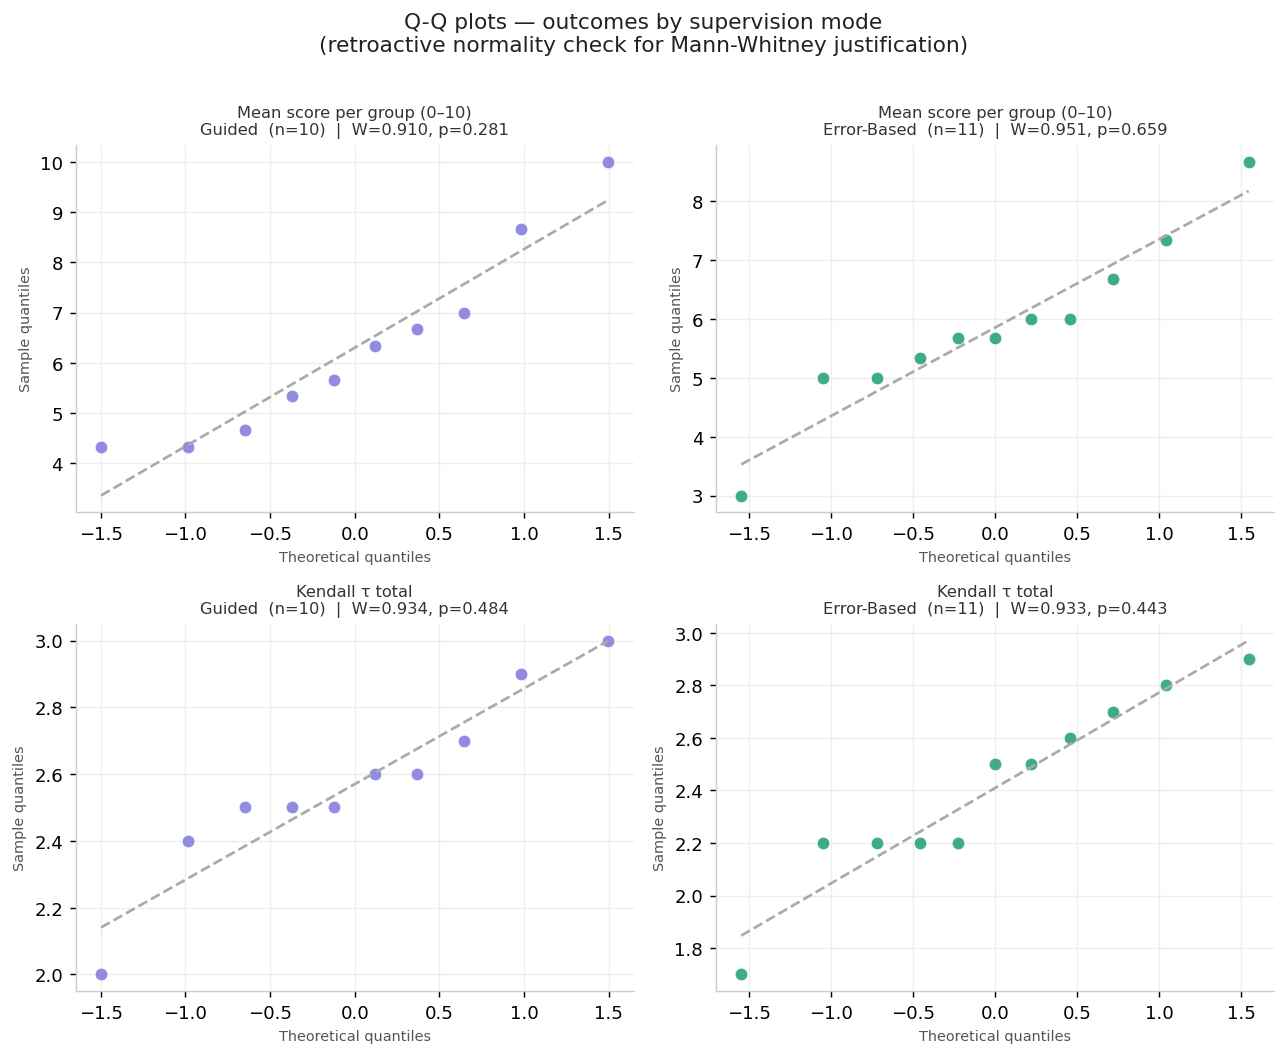

In [30]:
# ════════════════════════════════════════════════════════════════════════════
# 2. NORMALITY CHECKS — OUTCOMES (retroactive justification for Mann-Whitney)
# ════════════════════════════════════════════════════════════════════════════
RETRO     = {
    "test_score_mean":        "Mean score per group (0–10)",
    "test_kendall_tau_total": "Kendall τ total",
}


print("=" * 65)
print("NORMALITY CHECKS — OUTCOMES (per supervision mode group)")
print("Retroactive justification for Mann-Whitney test choice.")
print("=" * 65)

fig, axes = plt.subplots(len(RETRO), 2, figsize=(10, 4 * len(RETRO)))
fig.patch.set_facecolor("white")

for row_idx, (col, label) in enumerate(RETRO.items()):
    for col_idx, mode in enumerate(MODES):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")

        vals = df.loc[df["mode"] == mode, col].dropna()

        (osm, osr), (slope, intercept, r) = probplot(vals, dist="norm")
        ax.plot(osm, osr, "o", color=COLORS[mode], alpha=0.85,
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(osm, slope * np.array(osm) + intercept,
                color="#AAAAAA", lw=1.5, linestyle="--")

        W, p = shapiro(vals)
        ax.set_title(
            f"{label}\n{mode.replace('_','-').title()}  "
            f"(n={len(vals)})  |  W={W:.3f}, p={p:.3f}",
            fontsize=9, color="#333333", pad=6
        )
        ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
        ax.set_ylabel("Sample quantiles",      fontsize=8, color="#555555")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

        interp = "→ fail to reject normality" if p > .05 else "→ REJECT normality"
        print(f"  {label} | {mode:12s} | n={len(vals)} | "
              f"W={W:.3f}, p={p:.3f}  {interp}")
    print()

fig.suptitle("Q-Q plots — outcomes by supervision mode\n"
             "(retroactive normality check for Mann-Whitney justification)",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_outcomes.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### 3.1. Aggregate Scores

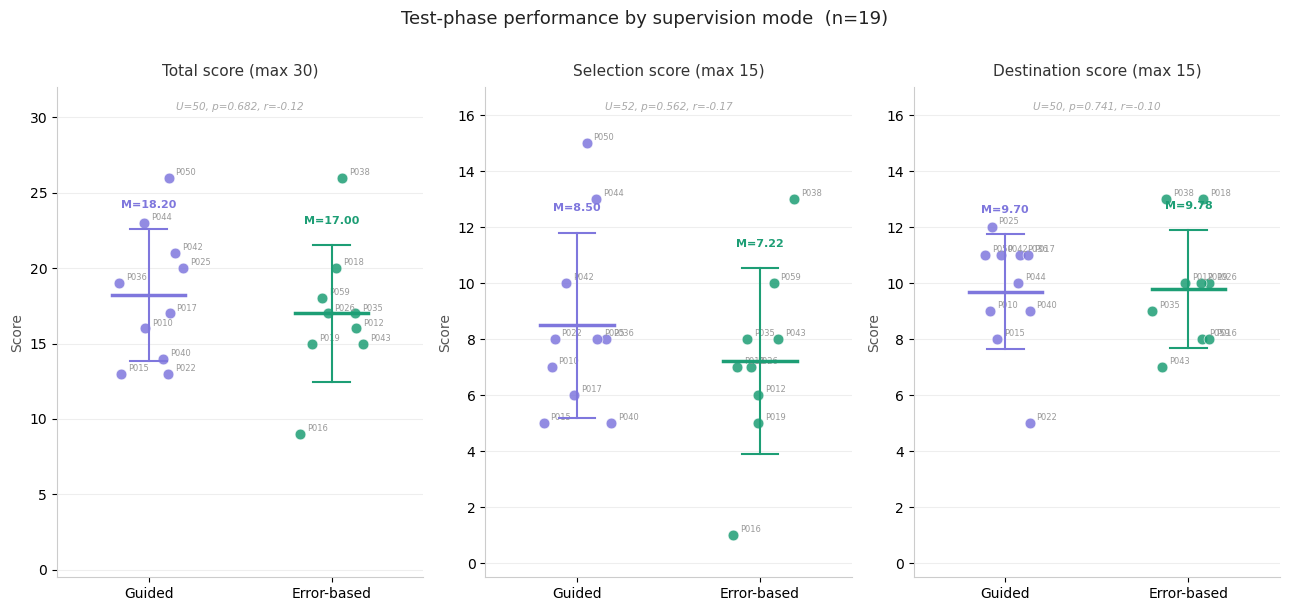

In [9]:
# ── Figure 1: score outcomes ──────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(13, 6), sharey=False)
fig1.patch.set_facecolor("white")

strip_panel(axes1[0], df, "test_total",       "Total score (max 30)",       32)
strip_panel(axes1[1], df, "test_sel_total",   "Selection score (max 15)",   17)
strip_panel(axes1[2], df, "test_dest_total",  "Destination score (max 15)", 17)

for ax in axes1:
    ax.set_ylabel("Score", fontsize=10, color="#555555")

fig1.suptitle(f"Test-phase performance by supervision mode  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig1_scores.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### 3.2. Kendall tau

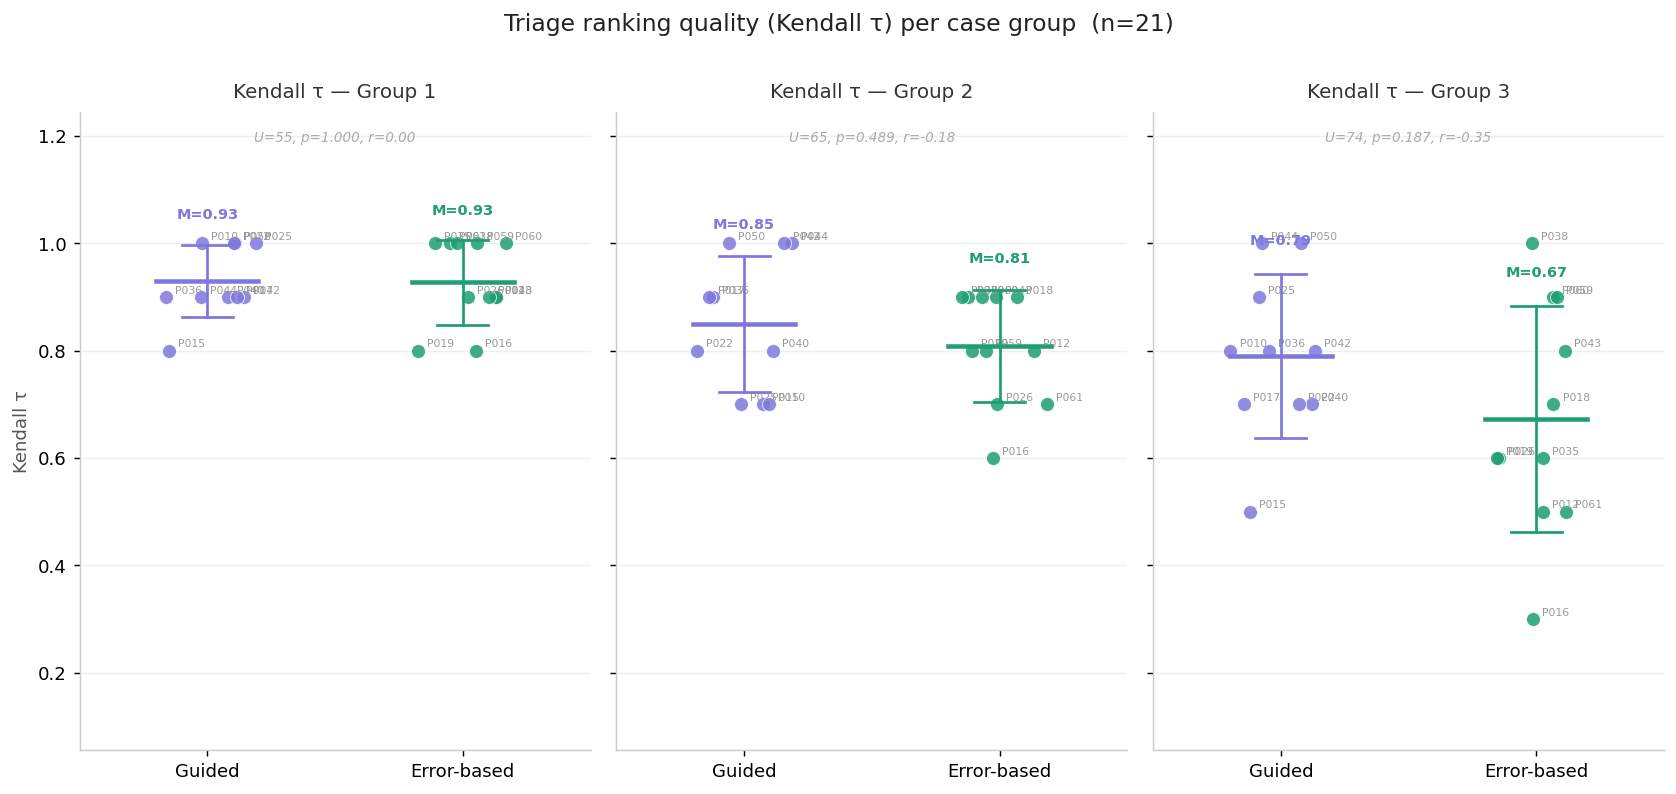

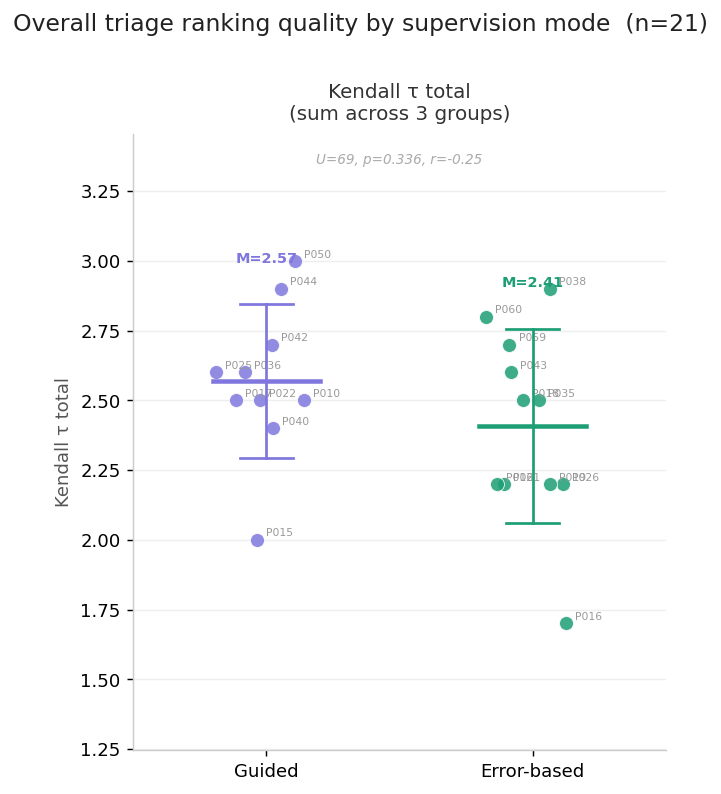

In [31]:
# ── Figure 2: Kendall tau per group (auto y-axis) ────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 6), sharey=True)
fig2.patch.set_facecolor("white")

for ax, g in zip(axes2, (1, 2, 3)):
    col  = f"test_g{g}_kendall_tau"
    vals = df[col].dropna()
    pad  = (vals.max() - vals.min()) * 0.35   # 35% padding above/below
    strip_panel(ax, df, col,
                f"Kendall τ — Group {g}",
                y_max=vals.max() + pad,
                y_min=vals.min() - pad)
    ax.axhline(0, color="#cccccc", lw=1, linestyle="--", zorder=0)

axes2[0].set_ylabel("Kendall τ", fontsize=10, color="#555555")
fig2.suptitle(f"Triage ranking quality (Kendall τ) per case group  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig2_kendall_by_group.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


# ── Figure 3: Kendall tau total (standalone) ─────────────────────────────────
col  = "test_kendall_tau_total"
vals = df[col].dropna()
pad  = (vals.max() - vals.min()) * 0.35

fig3, ax3 = plt.subplots(figsize=(5, 6))
fig3.patch.set_facecolor("white")

strip_panel(ax3, df, col,
            "Kendall τ total\n(sum across 3 groups)",
            y_max=vals.max() + pad,
            y_min=vals.min() - pad)

ax3.set_ylabel("Kendall τ total", fontsize=10, color="#555555")
fig3.suptitle(f"Overall triage ranking quality by supervision mode  (n={len(df)})",
              fontsize=13, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("fig3_kendall_total.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

#### (duration tested - not related to any analysis)

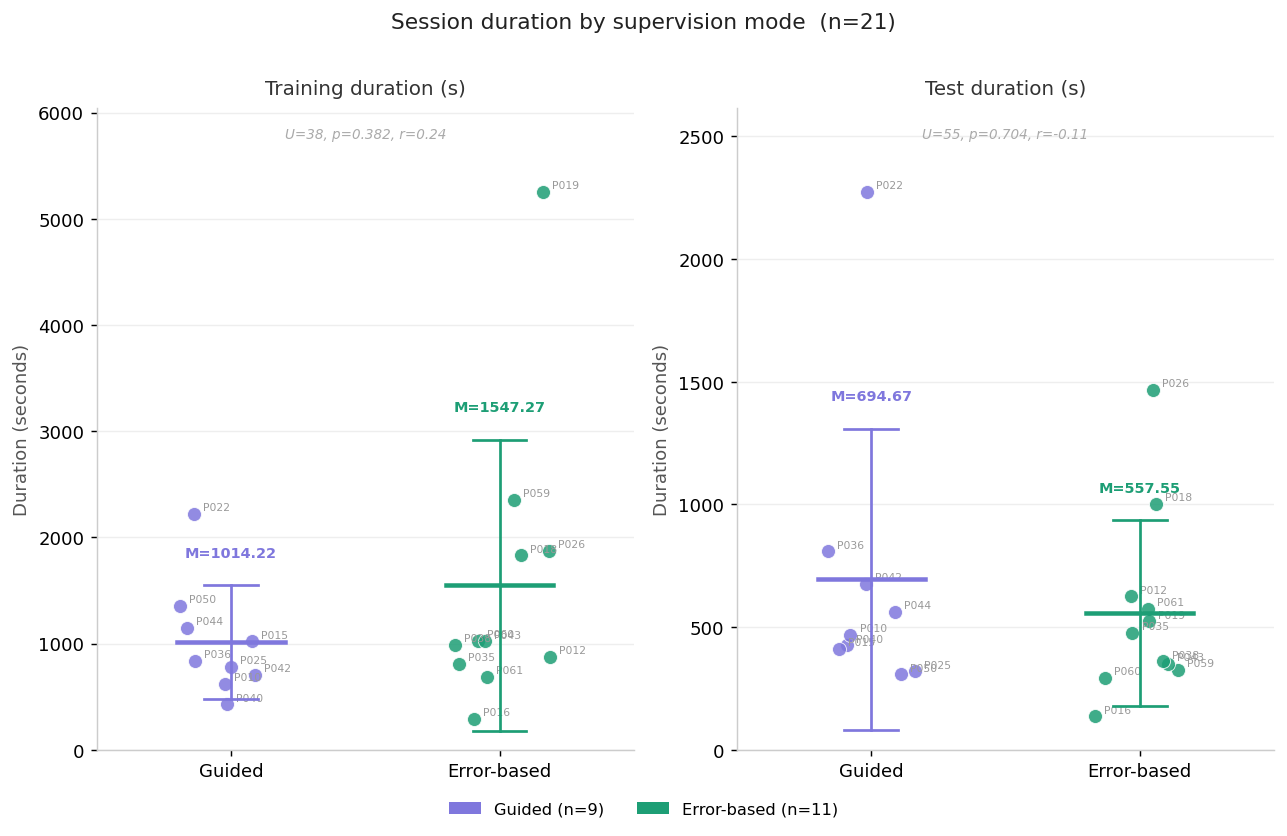

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=False)
fig.patch.set_facecolor("white")

strip_panel(axes[0], df_duration, "train_duration_sec",
            "Training duration (s)",
            y_max=df_duration["train_duration_sec"].max() * 1.15,
            y_min=0)

strip_panel(axes[1], df_duration, "test_duration_sec",
            "Test duration (s)",
            y_max=df_duration["test_duration_sec"].max() * 1.15,
            y_min=0)

for ax in axes:
    ax.set_ylabel("Duration (seconds)", fontsize=10, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df_duration[df_duration['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(f"Session duration by supervision mode  (n={len(df)})",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("duration_by_mode.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

VARIANCE HOMOGENEITY — Kendall τ by supervision mode
Levene's test (robust to non-normality)

  Group 1
    SD guided=0.067  SD error-based=0.079  Variance ratio=1.36
    Levene W=0.367, p=0.552  |  Fligner p=0.538

  Group 2
    SD guided=0.127  SD error-based=0.104  Variance ratio=0.68
    Levene W=1.309, p=0.267  |  Fligner p=0.267

  Group 3
    SD guided=0.152  SD error-based=0.210  Variance ratio=1.90
    Levene W=0.972, p=0.336  |  Fligner p=0.438

  Total
    SD guided=0.275  SD error-based=0.348  Variance ratio=1.60
    Levene W=0.845, p=0.369  |  Fligner p=0.556


Outcome  SD guided  SD error  Var ratio  Levene W  p (Levene)  p (Fligner)  sig
Group 1      0.067     0.079       1.36     0.367       0.552        0.538 n.s.
Group 2      0.127     0.104       0.68     1.309       0.267        0.267 n.s.
Group 3      0.152     0.210       1.90     0.972       0.336        0.438 n.s.
  Total      0.275     0.348       1.60     0.845       0.369        0.556 n.s.


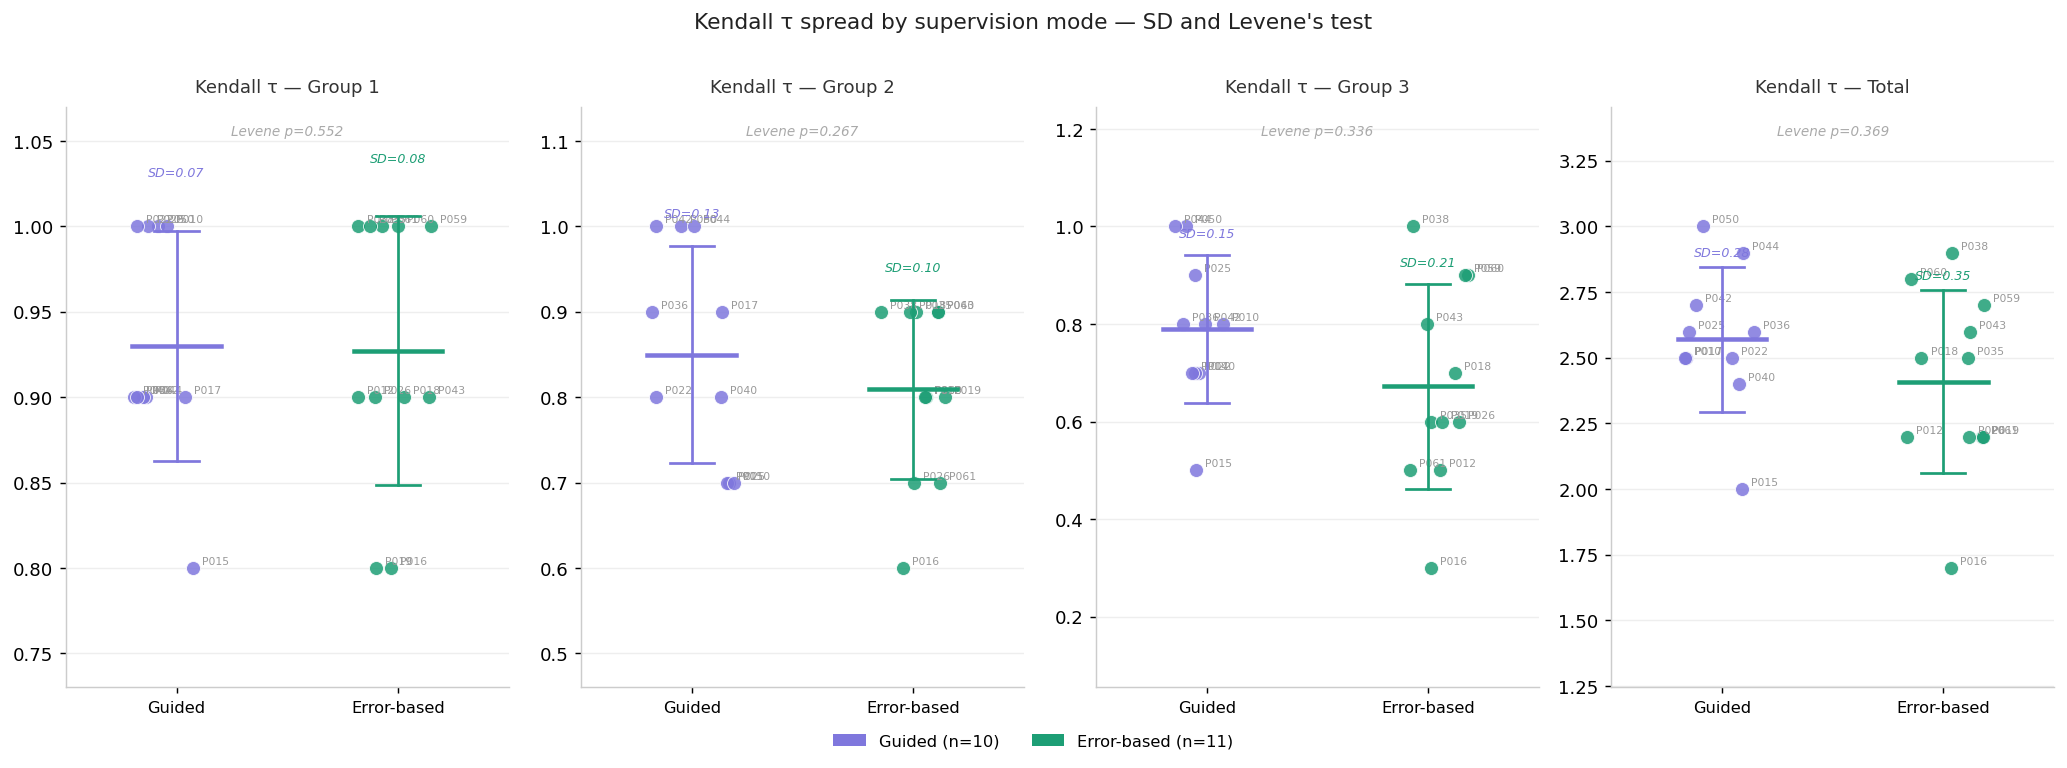

In [42]:
from scipy.stats import levene, fligner

print("=" * 65)
print("VARIANCE HOMOGENEITY — Kendall τ by supervision mode")
print("Levene's test (robust to non-normality)")
print("=" * 65)

TAU_COLS = {
    "test_g1_kendall_tau":    "Group 1",
    "test_g2_kendall_tau":    "Group 2",
    "test_g3_kendall_tau":    "Group 3",
    "test_kendall_tau_total": "Total",
}

results = []
for col, label in TAU_COLS.items():
    guided     = df.loc[df["mode"] == "guided",      col].dropna()
    error      = df.loc[df["mode"] == "error_based", col].dropna()

    # Levene's test
    stat_l, p_l = levene(guided, error, center="median")

    # Fligner-Killeen (non-parametric alternative — extra robustness)
    stat_f, p_f = fligner(guided, error)

    # Descriptive
    sd_g = guided.std(ddof=1)
    sd_e = error.std(ddof=1)
    var_ratio = (sd_e / sd_g) ** 2   # F-ratio of variances

    results.append({
        "Outcome":       label,
        "SD guided":     round(sd_g, 3),
        "SD error":      round(sd_e, 3),
        "Var ratio":     round(var_ratio, 2),
        "Levene W":      round(stat_l, 3),
        "p (Levene)":    round(p_l, 3),
        "p (Fligner)":   round(p_f, 3),
        "sig":           "n.s." if p_l > .05 else "*",
    })

    print(f"\n  {label}")
    print(f"    SD guided={sd_g:.3f}  SD error-based={sd_e:.3f}  "
          f"Variance ratio={var_ratio:.2f}")
    print(f"    Levene W={stat_l:.3f}, p={p_l:.3f}  |  "
          f"Fligner p={p_f:.3f}")

print("\n")
print(pd.DataFrame(results).to_string(index=False))

# ── Strip plot showing spread visually ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5), sharey=False)
fig.patch.set_facecolor("white")

for ax, (col, label) in zip(axes, TAU_COLS.items()):
    vals_all = df[col].dropna()
    pad = (vals_all.max() - vals_all.min()) * 0.35

    for mode in MODES:
        vals = df.loc[df["mode"] == mode, col].dropna().reset_index(drop=True)
        x0, c = X[mode], COLORS[mode]
        xs = x0 + rng.uniform(-0.10, 0.10, len(vals))

        ax.scatter(xs, vals, color=c, s=60, alpha=0.85,
                   edgecolors="white", linewidths=0.5, zorder=3)

        for xi, yi, pid in zip(xs, vals,
                                df.loc[df["mode"] == mode,
                                       "participant_id"].values):
            ax.annotate(pid, xy=(xi, yi), xytext=(5, 2),
                        textcoords="offset points", fontsize=6, color="#999999")

        m  = vals.mean()
        sd = vals.std(ddof=1)

        # mean crosshair
        ax.plot([x0-.10, x0+.10], [m, m], color=c, lw=2.5, zorder=5)
        ax.plot([x0, x0], [m-sd, m+sd], color=c, lw=1.5, zorder=5)
        for cap in [m-sd, m+sd]:
            ax.plot([x0-.05, x0+.05], [cap, cap], color=c, lw=1.5, zorder=5)

        # SD annotation
        ax.text(x0, m + sd + 0.03, f"SD={sd:.2f}",
                ha="center", va="bottom", fontsize=7,
                color=c, fontstyle="italic")

    # Levene p annotation
    guided = df.loc[df["mode"] == "guided",      col].dropna()
    error  = df.loc[df["mode"] == "error_based", col].dropna()
    _, p_l = levene(guided, error, center="median")
    p_str  = f"Levene p={p_l:.3f}" if p_l >= .001 else "Levene p<.001"
    ax.text(0.5, 0.97, p_str, transform=ax.transAxes,
            ha="center", va="top", fontsize=7.5,
            color="#aaaaaa", style="italic")

    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    ax.set_title(f"Kendall τ — {label}", fontsize=10, pad=8, color="#333333")
    ax.set_xlim(0, 1)
    ax.set_ylim(vals_all.min() - pad, vals_all.max() + pad)
    ax.set_xticks([0.25, 0.75])
    ax.set_xticklabels(["Guided", "Error-based"], fontsize=9)
    ax.grid(axis="y", color="#EEEEEE", linewidth=0.8, zorder=0)

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} "
                 f"(n={len(df[df['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Kendall τ spread by supervision mode — SD and Levene's test",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("variance_kendall.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Cognitive load and subjective experience by supervision mode



### 2.1. NASA-TLX

In [33]:

dims_to_show = BURDEN_DIMS + ["nasa_burden_mean"]
rows = []
for dim in dims_to_show:
    for mode in MODES:
        vals = df.loc[df["mode"] == mode, dim].dropna()
        rows.append({
            "Dimension": dim,
            "Mode":      mode,
            "n":         len(vals),
            "Mean":      round(vals.mean(), 1),
            "SD":        round(vals.std(ddof=1), 1),
            "Median":    round(vals.median(), 1),
            "Min":       vals.min(),
            "Max":       vals.max(),
        })
print(pd.DataFrame(rows).to_string(index=False))




         Dimension        Mode  n  Mean   SD  Median       Min        Max
       nasa_mental      guided 10  82.0 11.1    82.5 65.000000 100.000000
       nasa_mental error_based 11  84.1 15.8    90.0 50.000000 100.000000
     nasa_physical      guided 10  12.0 13.2    10.0  0.000000  35.000000
     nasa_physical error_based 11  17.7 19.4    10.0  0.000000  50.000000
     nasa_temporal      guided 10  60.0 29.1    57.5 15.000000 100.000000
     nasa_temporal error_based 11  55.0 20.2    50.0 20.000000  85.000000
nasa_performance_r      guided 10  50.5 26.9    50.0 10.000000  85.000000
nasa_performance_r error_based 11  59.1 20.8    60.0 10.000000  85.000000
       nasa_effort      guided 10  63.0 16.2    65.0 35.000000  90.000000
       nasa_effort error_based 11  70.0 21.3    70.0 25.000000 100.000000
  nasa_frustration      guided 10  53.0 19.3    52.5 30.000000 100.000000
  nasa_frustration error_based 11  71.8 22.8    75.0 30.000000 100.000000
  nasa_burden_mean      guided 10  53.

In [34]:
alpha_focal = cronbach_alpha(df_nasa[FOCAL_DIMS].dropna())
alpha_all   = cronbach_alpha(df_nasa[BURDEN_DIMS].dropna())

print(f"  Focal 3 (mental, effort, frustration) : α = {alpha_focal:.3f}")
print(f"  All 6 burden dimensions               : α = {alpha_all:.3f}")
print(f"  Threshold for composite use: α > 0.70")
print(f"  {'→ Composite justified' if alpha_focal > 0.70 else '→ Keep items separate — composite not justified'} (focal 3)")

  Focal 3 (mental, effort, frustration) : α = 0.492
  All 6 burden dimensions               : α = 0.609
  Threshold for composite use: α > 0.70
  → Keep items separate — composite not justified (focal 3)


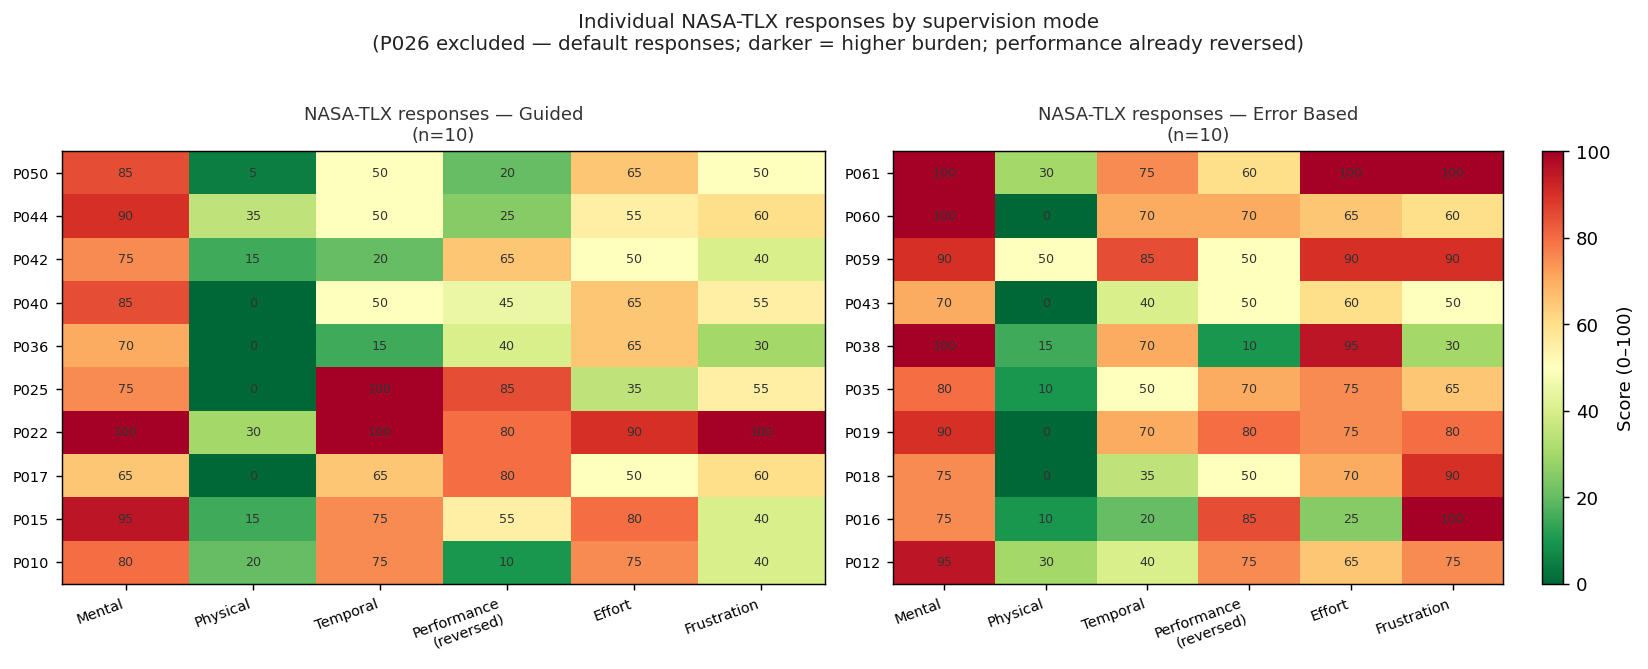

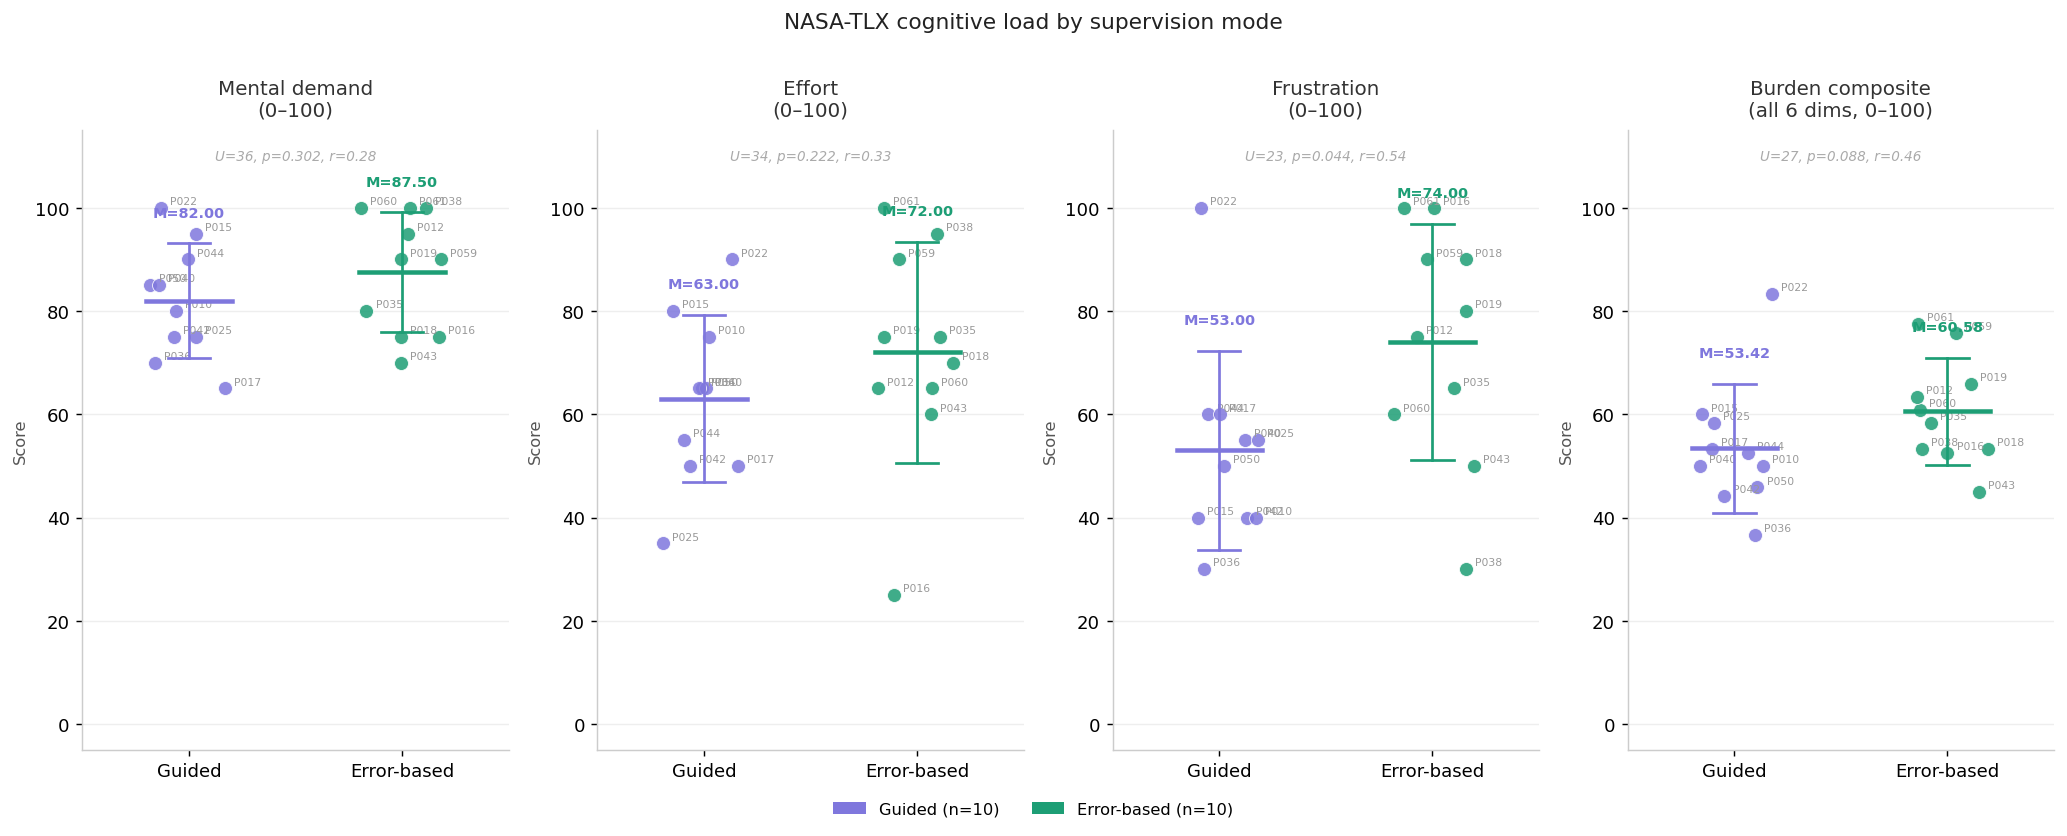

In [35]:
# ── Variability exploration — heatmap of individual responses ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

for ax, mode in zip(axes, MODES):
    sub = df_nasa[df_nasa["mode"] == mode][["participant_id"] + BURDEN_DIMS].set_index("participant_id")
    sub.columns = ["Mental", "Physical", "Temporal", "Performance\n(reversed)",
                   "Effort", "Frustration"]
    im = ax.imshow(sub.values, aspect="auto", cmap="RdYlGn_r",
                   vmin=0, vmax=100)
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, fontsize=8, rotation=20, ha="right")
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontsize=8)
    ax.set_title(f"NASA-TLX responses — {mode.replace('_',' ').title()}\n(n={len(sub)})",
                 fontsize=10, color="#333333")
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f"{sub.values[i,j]:.0f}",
                    ha="center", va="center", fontsize=7, color="#333333")

plt.colorbar(im, ax=axes[1], label="Score (0–100)")
fig.suptitle("Individual NASA-TLX responses by supervision mode\n"
             "(P026 excluded — default responses; darker = higher burden; performance already reversed)",
             fontsize=11, color="#222222", y=1.02)
plt.tight_layout()
plt.savefig("nasa_heatmap.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

plot_dims = [
    ("nasa_mental",      "Mental demand\n(0–100)"),
    ("nasa_effort",      "Effort\n(0–100)"),
    ("nasa_frustration", "Frustration\n(0–100)"),
    ("nasa_burden_mean", "Burden composite\n(all 6 dims, 0–100)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False)
fig.patch.set_facecolor("white")

for ax, (col, title) in zip(axes, plot_dims):
    strip_panel(ax, df_nasa, col, title, y_min=-5, y_max=115)
    ax.set_ylabel("Score", fontsize=9, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df_nasa[df_nasa['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("NASA-TLX cognitive load by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("nasa_by_mode.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()



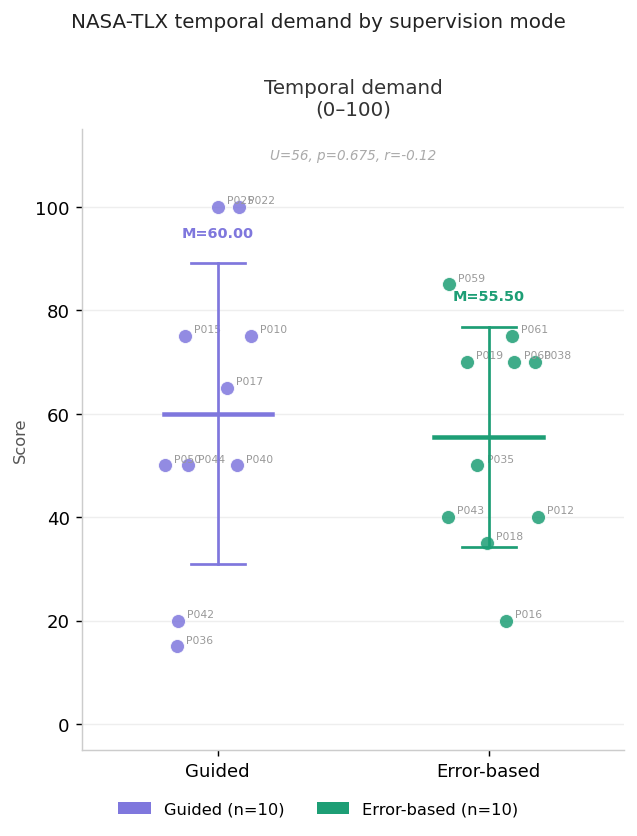

In [36]:
# ── Temporal demand — standalone figure ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 6))
fig.patch.set_facecolor("white")

strip_panel(ax, df_nasa, "nasa_temporal", "Temporal demand\n(0–100)", y_min=-5, y_max=115)
ax.set_ylabel("Score", fontsize=9, color="#555555")

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df_nasa[df_nasa['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("NASA-TLX temporal demand by supervision mode",
             fontsize=11, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("nasa_temporal.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [16]:

# ── Mann-Whitney summary table ────────────────────────────────────────────────
print("\n2.1c — Mann-Whitney U results (NASA-TLX)")
mw_rows = []
for col, label in plot_dims:
    a = df_nasa.loc[df["mode"] == "guided",      col].dropna()
    b = df_nasa.loc[df["mode"] == "error_based", col].dropna()
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    r    = round(1 - (2*u)/(len(a)*len(b)), 3)
    mw_rows.append({"Dimension": label.replace("\n"," "),
                    "U": u, "p": round(p,3), "r": r,
                    "sig": "n.s." if p>.05 else "*"})
print(pd.DataFrame(mw_rows).to_string(index=False))





2.1c — Mann-Whitney U results (NASA-TLX)
                           Dimension    U     p     r  sig
               Mental demand (0–100) 35.0 0.686 0.125 n.s.
                      Effort (0–100) 29.0 0.347 0.275 n.s.
                 Frustration (0–100) 20.5 0.090 0.488 n.s.
Burden composite (all 6 dims, 0–100) 25.0 0.196 0.375 n.s.


### 2.2. Subjective appraisal


2.2 — Subjective appraisal by mode


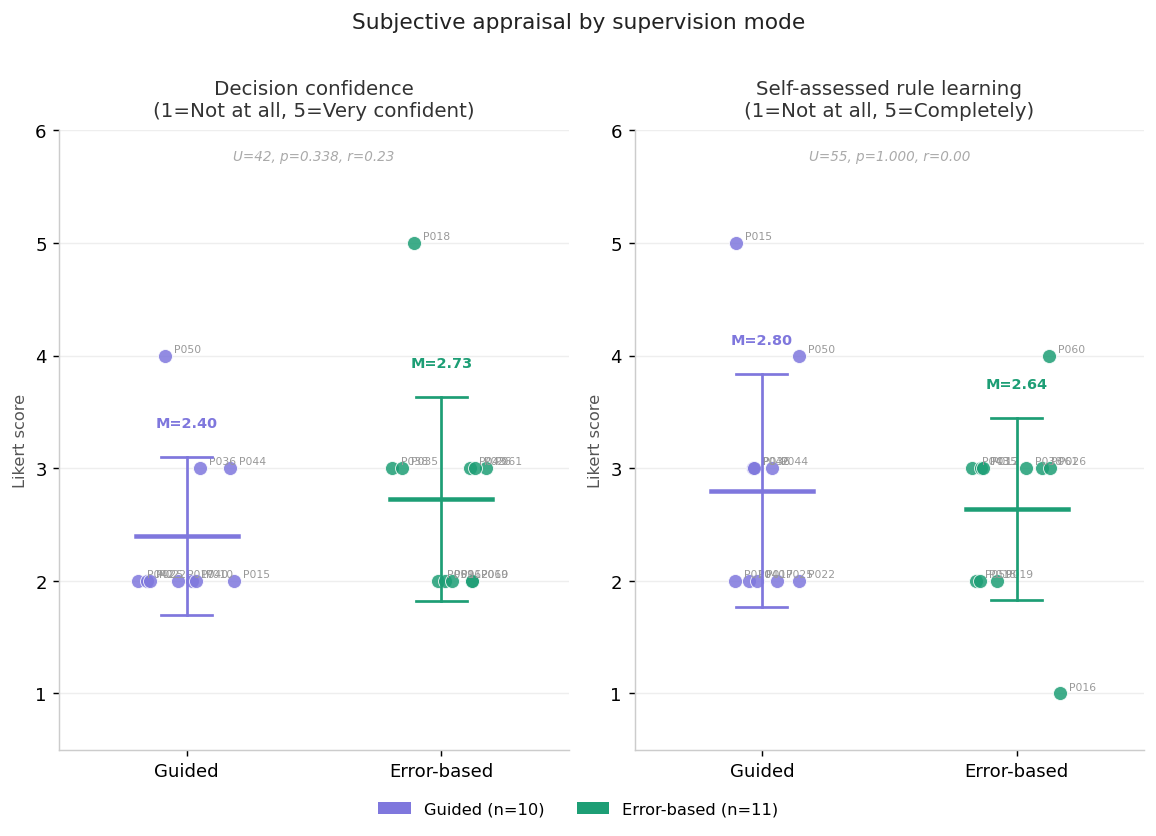


Discrepancy check — mean confidence vs mean test_total:
  guided        confidence=2.40/5   test_score_mean=6.30/10 (63%)
  error_based   confidence=2.73/5   test_score_mean=5.85/10 (58%)


In [37]:
# ════════════════════════════════════════════════════════════════════════════
# 2.2  Subjective appraisal — q_q2 (confidence) and q_q6 (self-assessed
#      rule learning) by mode; flag discrepancy with actual performance
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("2.2 — Subjective appraisal by mode")
print("="*60)

SUBJ_ITEMS = [
    ("q_q2", "Decision confidence\n(1=Not at all, 5=Very confident)"),
    ("q_q6", "Self-assessed rule learning\n(1=Not at all, 5=Completely)"),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
fig.patch.set_facecolor("white")

for ax, (col, title) in zip(axes, SUBJ_ITEMS):
    strip_panel(ax, df, col, title, y_min=0.5, y_max=6.0)
    ax.set_ylabel("Likert score", fontsize=9, color="#555555")
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))

handles = [mpatches.Patch(facecolor=COLORS[m],
           label=f"{'Guided' if m=='guided' else 'Error-based'} (n={len(df[df['mode']==m])})")
           for m in MODES]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Subjective appraisal by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("subjective_appraisal.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

# ── Discrepancy: confidence vs actual performance ─────────────────────────────
print("\nDiscrepancy check — mean confidence vs mean test_total:")
for mode in MODES:
    sub = df[df["mode"] == mode]
    conf  = sub["q_q2"].mean()
    score = sub["test_score_mean"].mean()
    score_pct = score / 10 * 100       # max is 10, not 30
    print(f"  {mode:12s}  confidence={conf:.2f}/5   "
          f"test_score_mean={score:.2f}/10 ({score_pct:.0f}%)")

## 3. Predictors of performance - exploratory regression

### 3.1. Correlation Matrix

Spearman correlations with Kendall τ total
             Predictor  n    r_s     p  sig
           Frustration 20 -0.433 0.056 n.s.
      Burden composite 20 -0.340 0.142 n.s.
   Decision confidence 21  0.307 0.176 n.s.
Self-assessed learning 21  0.299 0.189 n.s.
        Train time (s) 21  0.181 0.433 n.s.
         Task time (s) 21 -0.180 0.434 n.s.
                Effort 20 -0.113 0.636 n.s.
    Rule consultations 21 -0.055 0.813 n.s.
 Rule consult time (s) 21 -0.046 0.844 n.s.
         Mental demand 20 -0.014 0.954 n.s.


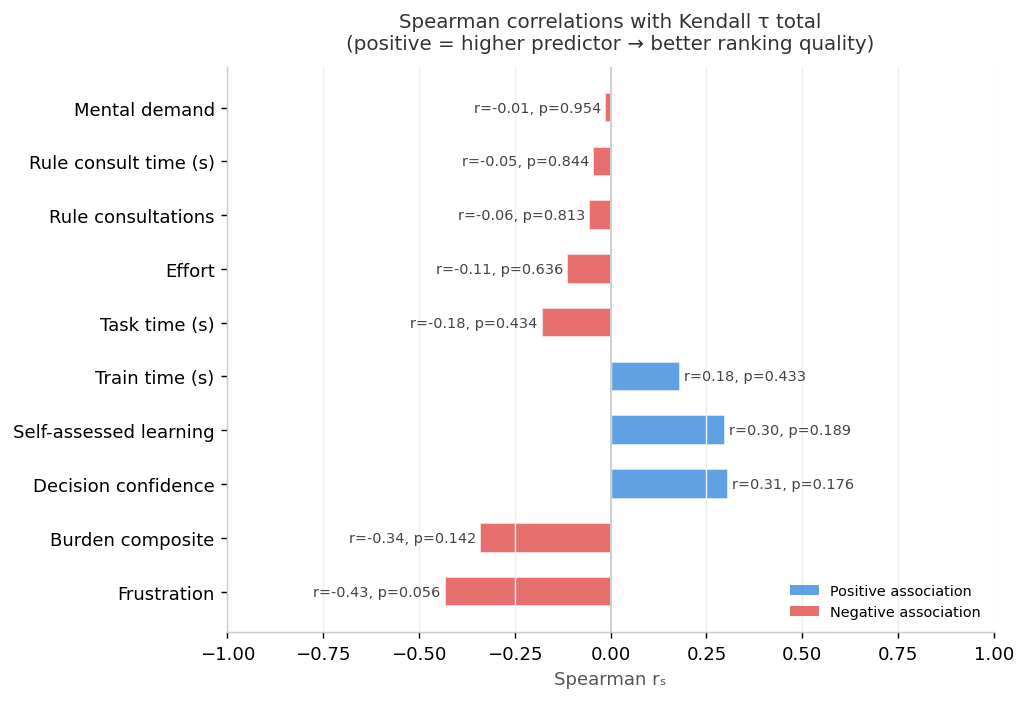

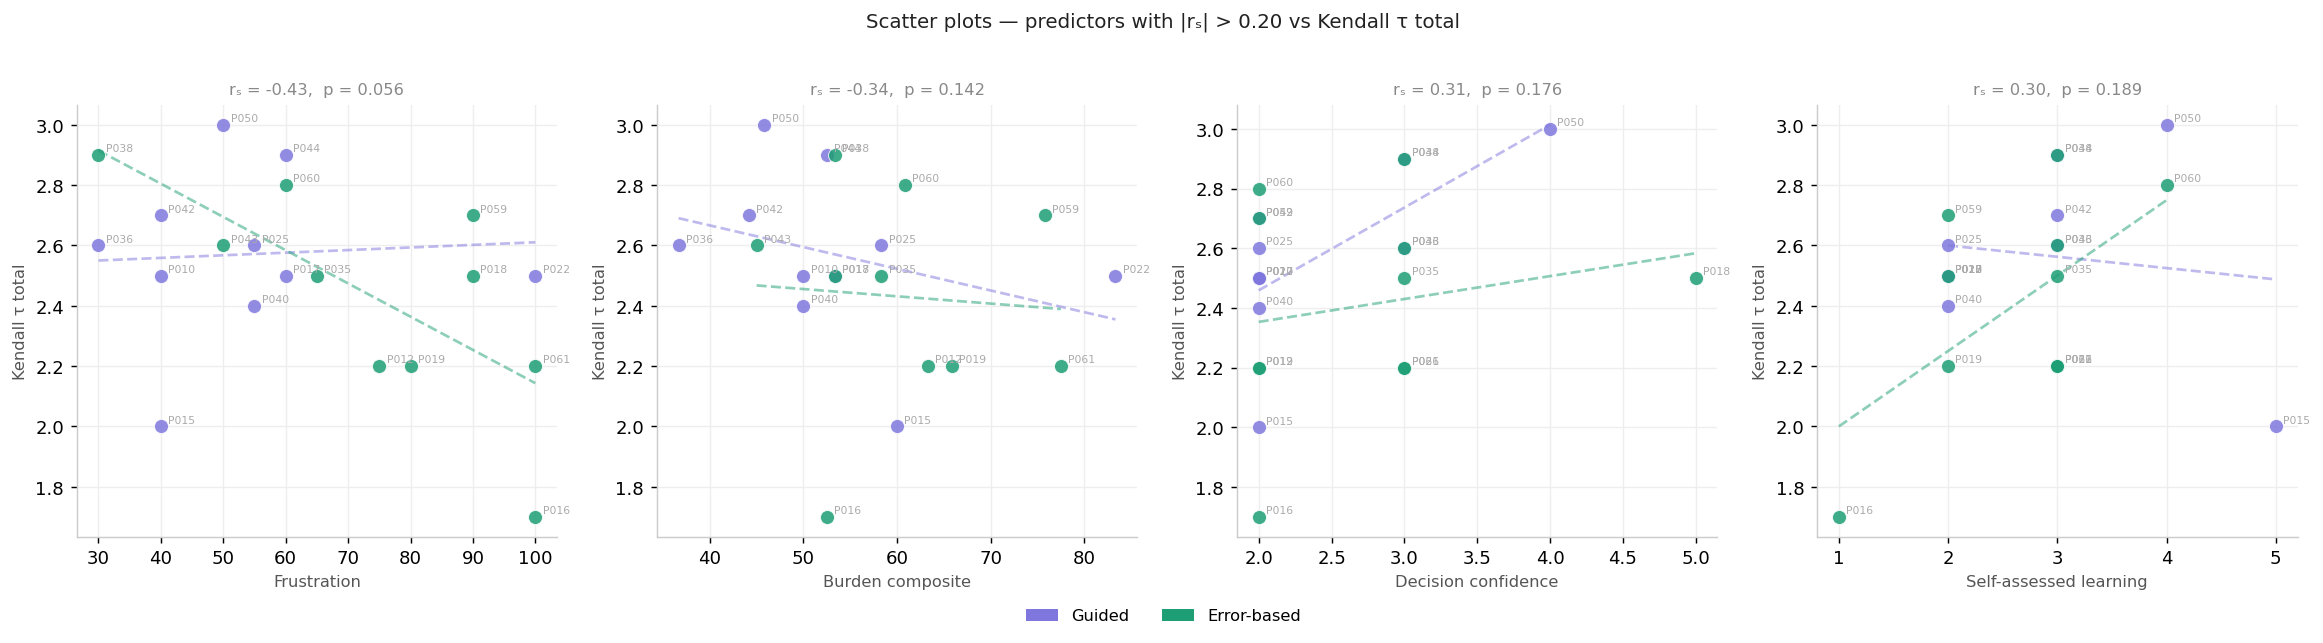

In [38]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1 — Spearman correlation matrix
#       Candidate predictors vs. test_kendall_tau_total
# ════════════════════════════════════════════════════════════════════════════

# ── Working frame: df + nasa columns from df_nasa (NaN for P026) ─────────────
df_corr = df.merge(
    df_nasa[["participant_id", "nasa_mental", "nasa_effort",
             "nasa_frustration", "nasa_burden_mean"]],
    on="participant_id", how="left",
    suffixes=("", "_nasa")
)
for col in ["nasa_mental", "nasa_effort", "nasa_frustration", "nasa_burden_mean"]:
    if f"{col}_nasa" in df_corr.columns:
        df_corr[col] = df_corr[f"{col}_nasa"]
        df_corr = df_corr.drop(columns=[f"{col}_nasa"])

# ── Define predictors ─────────────────────────────────────────────────────────
PREDICTORS = {
    "nasa_mental":          "Mental demand",
    "nasa_effort":          "Effort",
    "nasa_frustration":     "Frustration",
    "nasa_burden_mean":     "Burden composite",
    "test_rule_consult":    "Rule consultations",
    "test_rule_time_sec":   "Rule consult time (s)",
    "test_task_time_total": "Task time (s)",
    "train_duration_sec":   "Train time (s)",
    "q_q2":                 "Decision confidence",
    "q_q6":                 "Self-assessed learning",
}

OUTCOME       = "test_kendall_tau_total"
OUTCOME_LABEL = "Kendall τ total"

# ── Compute Spearman correlations ─────────────────────────────────────────────
from scipy.stats import spearmanr

corr_rows = []
for col, label in PREDICTORS.items():
    valid = df_corr[[col, OUTCOME]].dropna()
    r, p  = spearmanr(valid[col], valid[OUTCOME])
    corr_rows.append({
        "Predictor": label,
        "column":    col,
        "n":         len(valid),
        "r_s":       round(r, 3),
        "p":         round(p, 3),
        "sig":       "n.s." if p > .05 else ("*" if p > .01 else "**"),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("r_s", key=abs, ascending=False)
print("Spearman correlations with", OUTCOME_LABEL)
print(corr_df[["Predictor", "n", "r_s", "p", "sig"]].to_string(index=False))

# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")

bar_colors = ["#E24B4A" if r < 0 else "#378ADD" for r in corr_df["r_s"]]
ax.barh(corr_df["Predictor"], corr_df["r_s"],
        color=bar_colors, alpha=0.80, edgecolor="white", height=0.55)

for i, (_, row) in enumerate(corr_df.iterrows()):
    x_off = 0.01 if row["r_s"] >= 0 else -0.01
    ha    = "left" if row["r_s"] >= 0 else "right"
    label = f"r={row['r_s']:.2f}, p={row['p']:.3f}"
    if row["sig"] != "n.s.":
        label += f" {row['sig']}"
    ax.text(row["r_s"] + x_off, i, label,
            va="center", ha=ha, fontsize=8, color="#444444")

ax.axvline(0, color="#CCCCCC", lw=1)
ax.set_xlabel("Spearman rₛ", fontsize=10, color="#555555")
ax.set_title(f"Spearman correlations with {OUTCOME_LABEL}\n"
             f"(positive = higher predictor → better ranking quality)",
             fontsize=11, color="#333333", pad=10)
ax.set_xlim(-1, 1)
ax.grid(axis="x", color="#EEEEEE", linewidth=0.8, zorder=0)

legend_handles = [
    mpatches.Patch(facecolor="#378ADD", alpha=0.8, label="Positive association"),
    mpatches.Patch(facecolor="#E24B4A", alpha=0.8, label="Negative association"),
]
ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("spearman_correlations.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

# ── Scatter plots for top predictors (|r| > 0.20) ────────────────────────────
top_preds = corr_df[corr_df["r_s"].abs() > 0.20]["column"].tolist()

if top_preds:
    n_top  = len(top_preds)
    fig, axes = plt.subplots(1, n_top, figsize=(4.5 * n_top, 4.5))
    if n_top == 1:
        axes = [axes]
    fig.patch.set_facecolor("white")

    for ax, col in zip(axes, top_preds):
        label = PREDICTORS[col]
        for mode in MODES:
            sub = df_corr[df_corr["mode"] == mode][[col, OUTCOME]].dropna()
            ax.scatter(sub[col], sub[OUTCOME],
                       color=COLORS[mode], s=60, alpha=0.85,
                       edgecolors="white", linewidths=0.5, zorder=3)
            if len(sub) > 2:
                m, b, *_ = stats.linregress(sub[col], sub[OUTCOME])
                x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
                ax.plot(x_line, m * x_line + b,
                        color=COLORS[mode], lw=1.5, alpha=0.5, linestyle="--")

        for _, row in df_corr[[col, OUTCOME, "participant_id"]].dropna().iterrows():
            ax.annotate(row["participant_id"],
                        xy=(row[col], row[OUTCOME]),
                        xytext=(4, 2), textcoords="offset points",
                        fontsize=6, color="#aaaaaa")

        r_val = corr_df.loc[corr_df["column"] == col, "r_s"].values[0]
        p_val = corr_df.loc[corr_df["column"] == col, "p"].values[0]
        ax.set_xlabel(label, fontsize=9, color="#555555")
        ax.set_ylabel(OUTCOME_LABEL, fontsize=9, color="#555555")
        ax.set_title(f"rₛ = {r_val:.2f},  p = {p_val:.3f}",
                     fontsize=9, color="#888888", pad=6)
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

    handles = [mpatches.Patch(facecolor=COLORS[m],
               label=f"{'Guided' if m=='guided' else 'Error-based'}")
               for m in MODES]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f"Scatter plots — predictors with |rₛ| > 0.20 vs {OUTCOME_LABEL}",
                 fontsize=11, color="#222222", y=1.02)
    plt.tight_layout()
    plt.savefig("spearman_scatters.png", dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No predictors with |rₛ| > 0.20 found.")

In [41]:
# Run this to see which behavioural variables correlate with tau_total
behav_vars = {
    "test_rule_consult":    "Rule consultations",
    "test_rule_time_sec":   "Rule consult time (s)",
    "test_task_time_total": "Task time (s)",
    "train_duration_sec":   "Training duration (s)",
}

from scipy.stats import spearmanr
print(f"{'Variable':<30} {'rₛ':>8} {'p':>8} {'n':>5}")
print("-" * 55)
for col, label in behav_vars.items():
    valid = df[[col, "test_kendall_tau_total"]].dropna()
    r, p  = spearmanr(valid[col], valid["test_kendall_tau_total"])
    flag  = "← worth testing" if abs(r) > 0.20 else ""
    print(f"  {label:<28} {r:>8.3f} {p:>8.3f} {len(valid):>5}  {flag}")

Variable                             rₛ        p     n
-------------------------------------------------------
  Rule consultations             -0.055    0.813    21  
  Rule consult time (s)          -0.046    0.844    21  
  Task time (s)                  -0.180    0.434    21  
  Training duration (s)           0.181    0.433    21  


### 3.2. Normality Check

NORMALITY CHECKS — COVARIATES (per supervision mode group)

NOTE ON BOUNDED VARIABLES:
  q_q2 and q_q6 are 5-point ordinal scales (discrete, 1–5).
  Shapiro-Wilk is run for completeness but has near-zero power
  at n≈9-10 with only 5 possible values. The Q-Q plot is the
  more informative diagnostic for these variables.
  nasa_frustration (0–100 continuous) is more amenable to
  normality testing but remains bounded.

  Decision confidence (1–5) | guided       | n=10 | W=0.650, p=0.000  → REJECT normality
  Decision confidence (1–5) | error_based  | n=11 | W=0.734, p=0.001  → REJECT normality

  Frustration (0–100) | guided       | n=10 | W=0.838, p=0.042  → REJECT normality
  Frustration (0–100) | error_based  | n=10 | W=0.938, p=0.526  → fail to reject normality

  Self-assessed learning (1–5) | guided       | n=10 | W=0.791, p=0.011  → REJECT normality
  Self-assessed learning (1–5) | error_based  | n=11 | W=0.866, p=0.069  → fail to reject normality



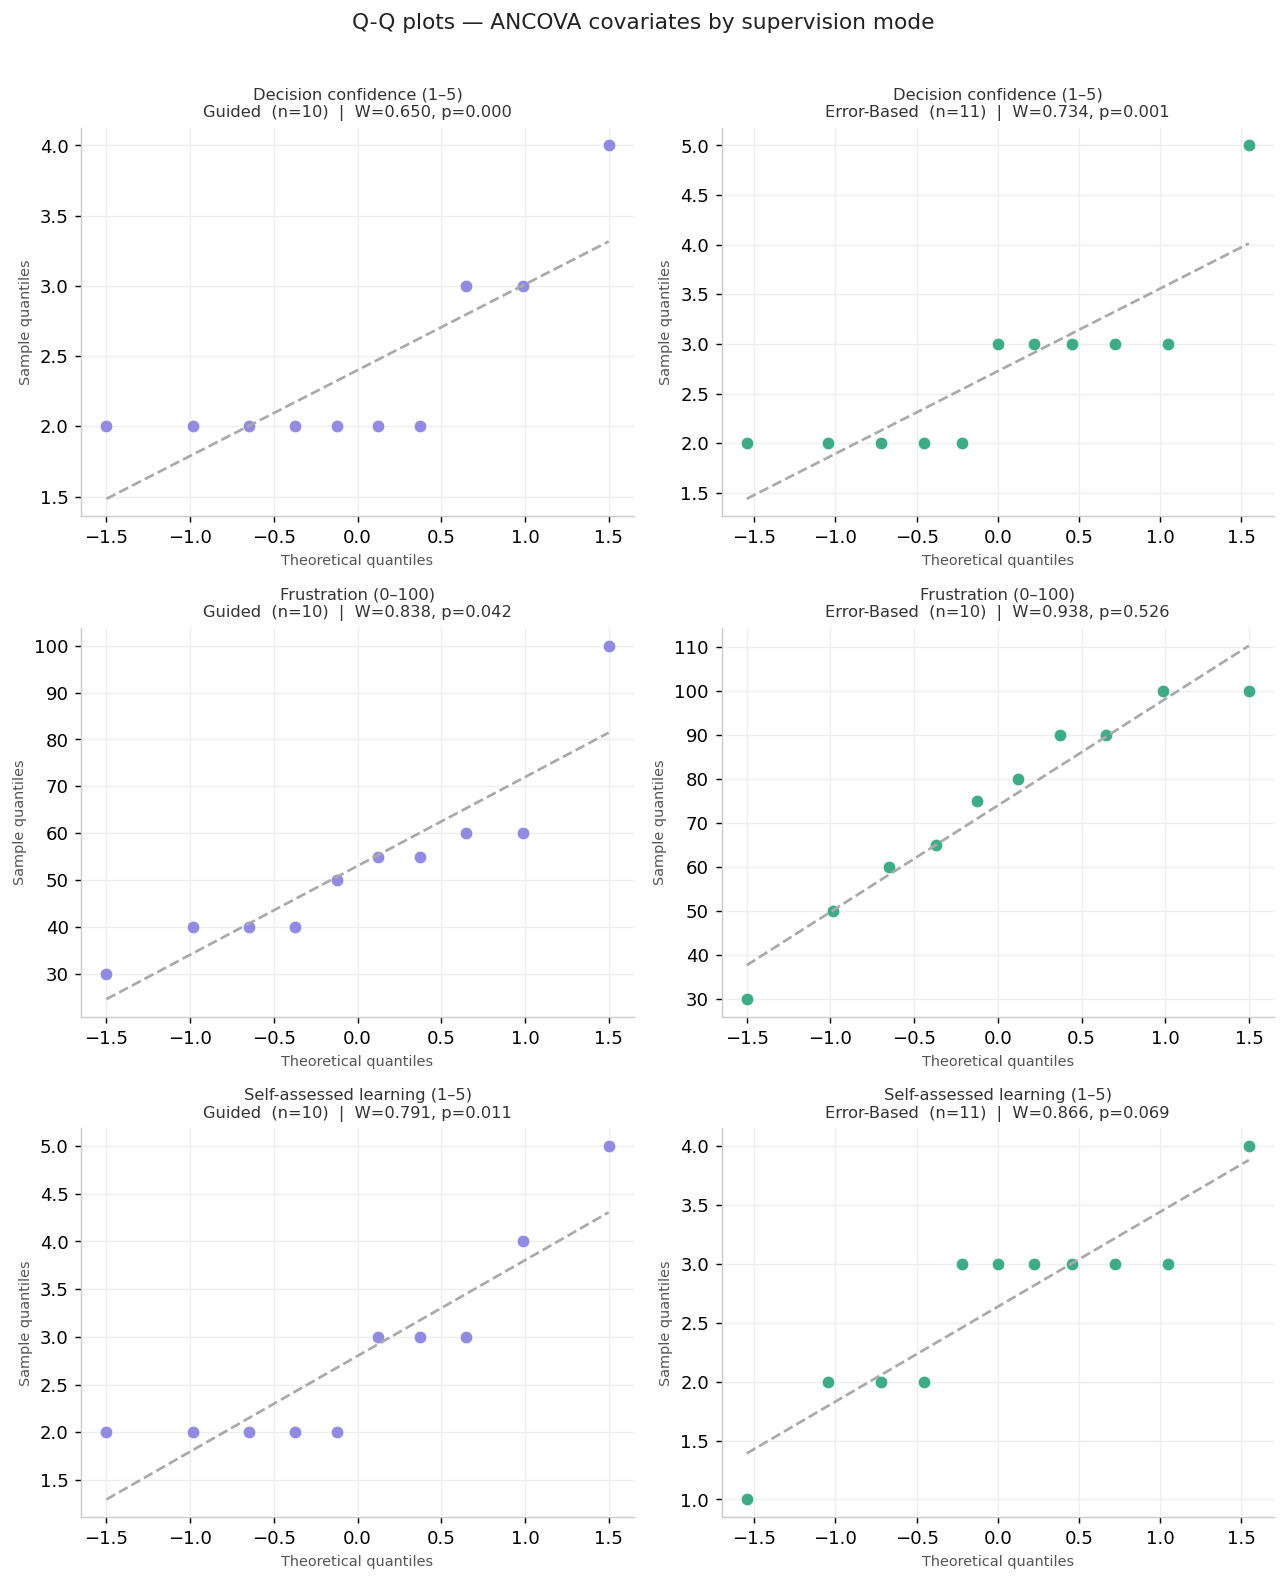

In [39]:
# ════════════════════════════════════════════════════════════════════════════
# NORMALITY CHECKS — COVARIATES
# ════════════════════════════════════════════════════════════════════════════

OUTCOME = "test_kendall_tau_total"
COVARS  = {
    "q_q2":              "Decision confidence (1–5)",
    "nasa_frustration":  "Frustration (0–100)",
    "q_q6":              "Self-assessed learning (1–5)",
}

print("=" * 65)
print("NORMALITY CHECKS — COVARIATES (per supervision mode group)")
print("=" * 65)
print("""
NOTE ON BOUNDED VARIABLES:
  q_q2 and q_q6 are 5-point ordinal scales (discrete, 1–5).
  Shapiro-Wilk is run for completeness but has near-zero power
  at n≈9-10 with only 5 possible values. The Q-Q plot is the
  more informative diagnostic for these variables.
  nasa_frustration (0–100 continuous) is more amenable to
  normality testing but remains bounded.
""")

fig, axes = plt.subplots(len(COVARS), 2, figsize=(10, 4 * len(COVARS)))
fig.patch.set_facecolor("white")

for row_idx, (col, label) in enumerate(COVARS.items()):
    for col_idx, mode in enumerate(MODES):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")

        src = df_nasa if col == "nasa_frustration" else df
        vals = src.loc[src["mode"] == mode, col].dropna()

        (osm, osr), (slope, intercept, r) = probplot(vals, dist="norm")
        ax.plot(osm, osr, "o", color=COLORS[mode], alpha=0.85,
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
        ax.plot(osm, slope * np.array(osm) + intercept,
                color="#AAAAAA", lw=1.5, linestyle="--")

        W, p = shapiro(vals)
        ax.set_title(
            f"{label}\n{mode.replace('_','-').title()}  "
            f"(n={len(vals)})  |  W={W:.3f}, p={p:.3f}",
            fontsize=9, color="#333333", pad=6
        )
        ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
        ax.set_ylabel("Sample quantiles",      fontsize=8, color="#555555")
        ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

        interp = "→ fail to reject normality" if p > .05 else "→ REJECT normality"
        print(f"  {label} | {mode:12s} | n={len(vals)} | "
              f"W={W:.3f}, p={p:.3f}  {interp}")
    print()

fig.suptitle("Q-Q plots — ANCOVA covariates by supervision mode",
             fontsize=12, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_covariates.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### 3.3. Ancova model comparison

In [40]:

# ════════════════════════════════════════════════════════════════════════════
# 3. ANCOVA — kendall_tau_total ~ mode [+ covariate]
# ════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ANCOVA — outcome: test_kendall_tau_total")
print("=" * 65)

def run_ancova(formula, data, label, n_perm=10000):
    from statsmodels.stats.anova import anova_lm

    model  = smf.ols(formula, data=data).fit()

    # ── Partial F for mode specifically ──────────────────────────────────────
    aov    = anova_lm(model, typ=2)
    mode_F = aov.loc["C(mode)", "F"] if "C(mode)" in aov.index else model.fvalue

    # ── Permutation on partial F for mode ────────────────────────────────────
    f_perm = []
    for _ in range(n_perm):
        d_p         = data.copy()
        d_p["mode"] = d_p["mode"].sample(frac=1).values
        try:
            aov_p = anova_lm(smf.ols(formula, data=d_p).fit(), typ=2)
            f_perm.append(aov_p.loc["C(mode)", "F"])
        except Exception:
            pass
    p_perm = np.mean(np.array(f_perm) >= mode_F)

    print(f"\n  {'─'*55}")
    print(f"  Model: {label}  (n={len(data)})")
    print(f"  {'─'*55}")
    print(model.summary2().tables[1].to_string())
    print(f"\n  R² = {model.rsquared:.3f}   Adj R² = {model.rsquared_adj:.3f}")
    print(f"  Mode partial F = {mode_F:.3f}")
    print(f"  p mode (parametric) = {model.pvalues.get('C(mode)[T.guided]', float('nan')):.3f}")
    print(f"  p mode (permutation, {n_perm} perms) = {p_perm:.3f}")
    return model, p_perm

# ── Data frames per model (dropna on relevant columns) ───────────────────────
df_m0 = df_ancova[["test_kendall_tau_total","mode"]].dropna()
df_m1 = df_ancova[["test_kendall_tau_total","mode","q_q2"]].dropna()
df_m2 = df_ancova[["test_kendall_tau_total","mode","nasa_frustration"]].dropna()
df_m3 = df_ancova[["test_kendall_tau_total","mode","q_q6"]].dropna()

m0, p0 = run_ancova("test_kendall_tau_total ~ C(mode)",
                    df_m0, "Baseline: τ ~ mode")
m1, p1 = run_ancova("test_kendall_tau_total ~ C(mode) + q_q2",
                    df_m1, "Model 1:  τ ~ mode + decision confidence")
m2, p2 = run_ancova("test_kendall_tau_total ~ C(mode) + nasa_frustration",
                    df_m2, "Model 2:  τ ~ mode + frustration")
m3, p3 = run_ancova("test_kendall_tau_total ~ C(mode) + q_q6",
                    df_m3, "Model 3:  τ ~ mode + self-assessed learning")


# ── Comparison table ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL COMPARISON — mode coefficient across models")
print("=" * 65)
print(f"{'Model':<45} {'n':>4} {'mode coef':>10} {'p (param)':>10} "
      f"{'p (perm)':>10} {'Adj R²':>8}")
print("-" * 95)

models = [
    ("τ ~ mode",                          df_m0, m0, p0),
    ("τ ~ mode + decision confidence",    df_m1, m1, p1),
    ("τ ~ mode + frustration",            df_m2, m2, p2),
    ("τ ~ mode + self-assessed learning", df_m3, m3, p3),
]

for label, data_, m, p_perm in models:
    coef = m.params.get("C(mode)[T.guided]", np.nan)
    p_c  = m.pvalues.get("C(mode)[T.guided]", np.nan)
    print(f"  {label:<43} {len(data_):>4} {coef:>10.4f} {p_c:>10.3f} "
          f"{p_perm:>10.3f} {m.rsquared_adj:>8.3f}")


# ── Residual Q-Q plots for each fitted model ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.patch.set_facecolor("white")

for ax, (label, _, m, _) in zip(axes, models):
    resid = m.resid
    (osm, osr), (slope, intercept, r) = probplot(resid, dist="norm")
    ax.plot(osm, osr, "o", color="#378ADD", alpha=0.8,
            markersize=7, markeredgecolor="white", markeredgewidth=0.5)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="#AAAAAA", lw=1.5, linestyle="--")
    W, p = shapiro(resid)
    ax.set_title(f"{label}\nResiduals  W={W:.3f}, p={p:.3f}",
                 fontsize=8, color="#333333", pad=6)
    ax.set_xlabel("Theoretical quantiles", fontsize=8, color="#555555")
    ax.set_ylabel("Residuals",             fontsize=8, color="#555555")
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#CCCCCC")
    ax.grid(color="#EEEEEE", linewidth=0.8, zorder=0)

fig.suptitle("Q-Q plots of ANCOVA residuals — normality of residuals check",
             fontsize=11, color="#222222", y=1.01)
plt.tight_layout()
plt.savefig("qq_ancova_residuals.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

ANCOVA — outcome: test_kendall_tau_total


KeyboardInterrupt: 